# Fase 4b — Análisis NLP de Comentarios

Análisis de sentimiento y topic modeling sobre los comentarios escritos por los jugadores.

**Entradas:** `data/processed/sessions.parquet`  
**Salidas:** `data/exports/nlp_results.csv`, figuras `reports/figures/fig6_*.png`

> **Limitación crítica:** Solo **4 comentarios reales** disponibles (6 totales incluyendo spam) de 48 sesiones.
> Los resultados son estrictamente **cualitativos e ilustrativos**.
> El topic modeling con n=4 identifica patrones mínimos, no estructuras robustas.
> El modelo BERT multilingüe procesa correctamente español.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..') / 'src'))
from nlp_utils import (get_sentiment_scores, extract_topics_tfidf,
                        extract_topics_nmf, assign_dominant_topic)
from visualization import PALETTE_ELEM

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
MODELS_DIR    = Path('..') / 'models'
for d in [EXPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preparación de comentarios — TFM-27

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')

# Sesiones con comentario
df_comments = df_sessions[df_sessions['hasComment'] == True].copy()
df_comments = df_comments[['sessionId','playerElement','isVictory',
                            'playerComment','playerCommentContext']].reset_index(drop=True)

df_comments['texto_completo'] = (
    df_comments['playerComment'].fillna('') + ' ' +
    df_comments['playerCommentContext'].fillna('')
).str.strip()

df_comments['comment_length'] = df_comments['playerComment'].str.len().fillna(0).astype(int)

# --- Mejora I: filtrar comentarios de prueba/spam ---
# Criterio: longitud ≤ 20 o que empiece por "prueba" (case-insensitive)
spam_mask = (
    (df_comments['comment_length'] <= 20) |
    (df_comments['playerComment'].str.lower().str.startswith('prueba', na=False))
)
df_real = df_comments[~spam_mask].copy().reset_index(drop=True)
df_spam = df_comments[spam_mask].copy().reset_index(drop=True)

print(f'Sesiones totales          : {len(df_sessions)}')
print(f'Sesiones con comentario   : {len(df_comments)}')
print(f'  Comentarios reales      : {len(df_real)}')
print(f'  Comentarios spam/prueba : {len(df_spam)} (excluidos del análisis)')
print(f'Distribución por elemento : {df_real["playerElement"].value_counts().to_dict()}')
print(f'Victorias comentadas       : {df_real["isVictory"].sum()}/{len(df_real)}')
print()
print('Comentarios reales:')
for _, r in df_real.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length}')
    print(f'    "{r.playerComment}"')
print()
print('Excluidos (spam/prueba):')
for _, r in df_spam.iterrows():
    print(f'  [{r.playerElement}] Victoria={r.isVictory} | len={r.comment_length} — "{r.playerComment}"')

Sesiones totales          : 52
Sesiones con comentario   : 7
  Comentarios reales      : 5
  Comentarios spam/prueba : 2 (excluidos del análisis)
Distribución por elemento : {'Wind': 2, 'Earth': 2, 'Fire': 1}
Victorias comentadas       : 4/5

Comentarios reales:
  [Wind] Victoria=True | len=67
    "Los arqueros no me estaban atacando, me perseguian pero no atacaban"
  [Fire] Victoria=True | len=256
    "No esta mal el juego pero en una de las salas del ultimo nivel al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala"
  [Wind] Victoria=False | len=242
    "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar  la estrategia. Falta poner música de calidad como el heavy metal!!!! Me lo he pasado muy bien pero no lo he acabado porque no he podido cargar la partida salvada."
  [Earth] Victoria=True | len=61
    "Arreglar el te

## 2. `src/nlp_utils.py` ya creado — test rápido — TFM-28

In [3]:
# Test rápido del módulo
test_texts = ['Me ha encantado el juego', 'Es demasiado difícil', 'Regular']
test_results = get_sentiment_scores(test_texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))
for t, r in zip(test_texts, test_results):
    print(f'{r["stars"]}★ ({r["score"]:.2f}) — "{t}"')
print('\nnlp_utils.py funcionando correctamente')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

5★ (1.00) — "Me ha encantado el juego"
2★ (0.25) — "Es demasiado difícil"
3★ (0.50) — "Regular"

nlp_utils.py funcionando correctamente


## 3. Análisis de sentimiento — TFM-28

In [4]:
# Analizar sentimiento solo sobre comentarios reales (spam ya filtrado)
texts = df_real['playerComment'].fillna('').tolist()
print('Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...')
sentiment_results = get_sentiment_scores(texts, cache_dir=str(MODELS_DIR / 'nlp_cache'))

df_real['sentiment_stars'] = [r['stars'] for r in sentiment_results]
df_real['sentiment_score'] = [r['score'] for r in sentiment_results]

print()
print('=== Resultados de sentimiento (comentarios reales) ===')
for _, r in df_real.iterrows():
    stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
    print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:65]}..."')

print(f'\nMedia sentimiento (reales) : {df_real["sentiment_score"].mean():.3f}')
print(f'Mediana                    : {df_real["sentiment_score"].median():.3f}')
print()
print('Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.')

Analizando sentimiento con nlptown/bert-base-multilingual-uncased-sentiment...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Resultados de sentimiento (comentarios reales) ===
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacab..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al..."
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Media sentimiento (reales) : 0.400
Mediana                    : 0.500

Nota: comentarios spam excluidos tenían score=0.75 inflando artificialmente la media.


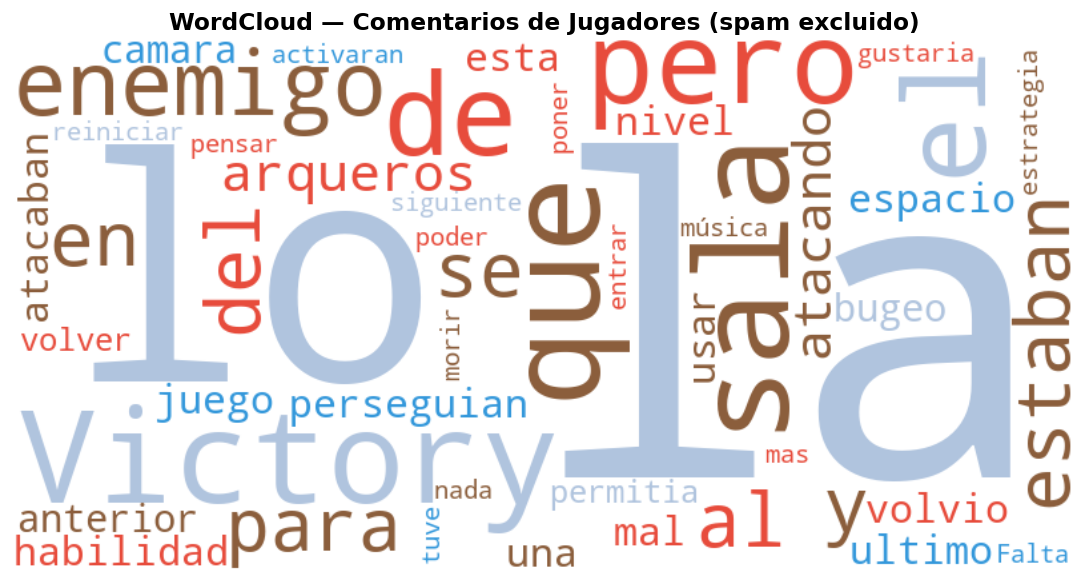

fig6_1_wordcloud.png guardado


In [5]:
# WordCloud de comentarios reales únicamente
texto_total = ' '.join(df_real['texto_completo'].tolist())

def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    colors = list(PALETTE_ELEM.values())
    return colors[hash(word) % len(colors)]

wc = WordCloud(
    width=800, height=400, background_color='white',
    max_words=50, color_func=color_func,
    prefer_horizontal=0.8, collocations=False
)
wc.generate(texto_total)

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud — Comentarios de Jugadores (spam excluido)', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_1_wordcloud.png', bbox_inches='tight')
plt.show()
print('fig6_1_wordcloud.png guardado')

## 4. Topic modeling TF-IDF + NMF — TFM-41

In [6]:
# TF-IDF sobre textos reales
texts_list = df_real['texto_completo'].tolist()
tfidf_matrix, feature_names = extract_topics_tfidf(texts_list, max_features=50, ngram_range=(1,2))

print(f'Vocabulario TF-IDF: {len(feature_names)} términos')

# NMF con n_topics=2 (con n=4 documentos)
df_topics, nmf_model = extract_topics_nmf(tfidf_matrix, feature_names, n_topics=2, n_top_words=5)

print('\n=== Tópicos NMF ===')
for _, row in df_topics.iterrows():
    print(f'  Tópico {row["topic_id"]}: {row["top_words"]}')

# Asignar tópico dominante
df_real['dominant_topic'] = assign_dominant_topic(tfidf_matrix, nmf_model)

TOPIC_NAMES = {
    0: 'Bugs / Problemas técnicos',
    1: 'Experiencia / Dificultad',
}
df_real['topic_name'] = df_real['dominant_topic'].map(TOPIC_NAMES)
print('\nTópico asignado por comentario:')
for _, r in df_real.iterrows():
    print(f'  Tópico {r.dominant_topic} ({r.topic_name}) — [{r.playerElement}]')

Vocabulario TF-IDF: 50 términos

=== Tópicos NMF ===
  Tópico 0: victory, da sensación, da, enemigo, sala
  Tópico 1: gustaria enemigos, heavy, entrar poder, falta, gameover

Tópico asignado por comentario:
  Tópico 0 (Bugs / Problemas técnicos) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Fire]
  Tópico 1 (Experiencia / Dificultad) — [Wind]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]
  Tópico 0 (Bugs / Problemas técnicos) — [Earth]


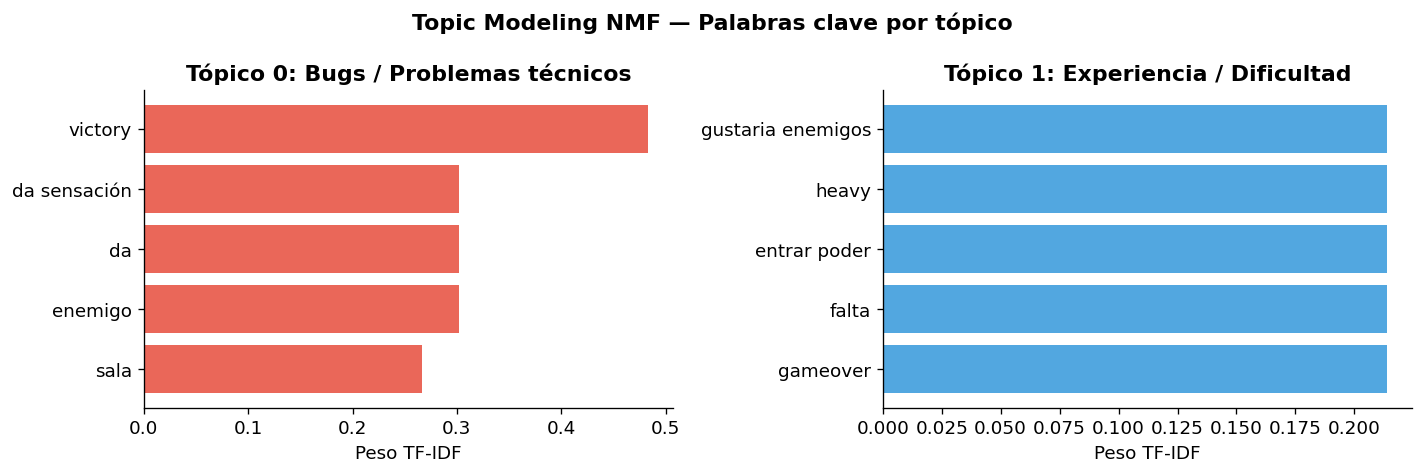

fig6_4_topics.png guardado


In [7]:
# Visualizar top palabras por tópico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#3498db']

for idx, (ax, (_, row)) in enumerate(zip(axes, df_topics.iterrows())):
    words   = row['top_words'].split(', ')
    weights = row['weights']
    ax.barh(words[::-1], weights[::-1], color=colors[idx], alpha=0.85)
    ax.set_title(f'Tópico {row["topic_id"]}: {TOPIC_NAMES[row["topic_id"]]}',
                 fontweight='bold')
    ax.set_xlabel('Peso TF-IDF')

fig.suptitle('Topic Modeling NMF — Palabras clave por tópico', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_4_topics.png', bbox_inches='tight')
plt.show()
print('fig6_4_topics.png guardado')

## 5. Cross-analysis sentimiento × elemento × victoria — TFM-42

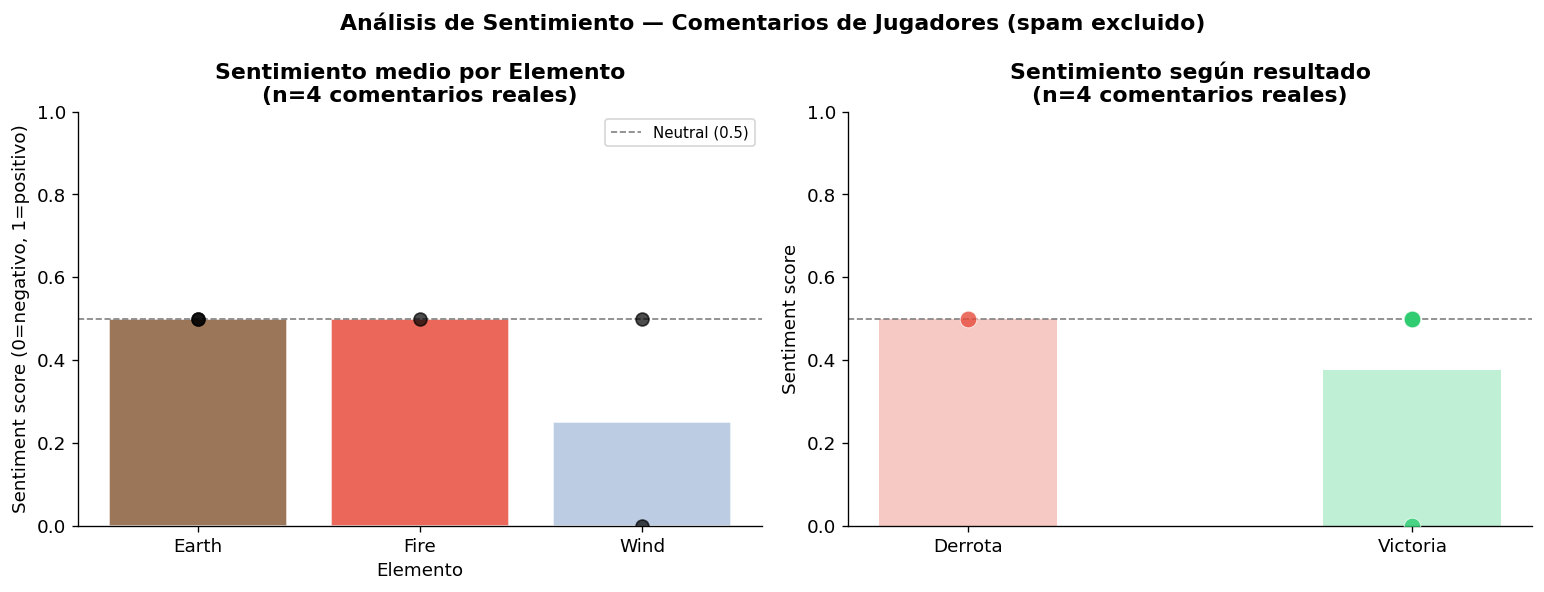

fig6_2_sentimiento_elemento.png guardado


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sentimiento por elemento
elem_order = df_real.groupby('playerElement')['sentiment_score'].mean().sort_values(ascending=False).index
colors_elem = [PALETTE_ELEM.get(e, '#888') for e in elem_order]
axes[0].bar(elem_order, df_real.groupby('playerElement')['sentiment_score'].mean()[elem_order],
            color=colors_elem, alpha=0.85, edgecolor='white')

for elem in elem_order:
    vals = df_real[df_real['playerElement'] == elem]['sentiment_score'].values
    x_positions = [list(elem_order).index(elem)] * len(vals)
    axes[0].scatter(x_positions, vals, color='black', s=60, zorder=5, alpha=0.7)

axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('Sentimiento medio por Elemento\n(n=4 comentarios reales)', fontweight='bold')
axes[0].set_xlabel('Elemento')
axes[0].set_ylabel('Sentiment score (0=negativo, 1=positivo)')
axes[0].legend(fontsize=9)

# Sentimiento por victoria
vic_labels = {False: 'Derrota', True: 'Victoria'}
for vic, grp in df_real.groupby('isVictory'):
    axes[1].scatter([vic_labels[vic]] * len(grp), grp['sentiment_score'],
                    s=100, alpha=0.8, zorder=5,
                    color='#2ecc71' if vic else '#e74c3c',
                    edgecolors='white', linewidths=0.5)
    axes[1].bar([vic_labels[vic]], grp['sentiment_score'].mean(),
                color='#2ecc71' if vic else '#e74c3c', alpha=0.3, width=0.4)

axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title('Sentimiento según resultado\n(n=4 comentarios reales)', fontweight='bold')
axes[1].set_ylabel('Sentiment score')

fig.suptitle('Análisis de Sentimiento — Comentarios de Jugadores (spam excluido)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_2_sentimiento_elemento.png', bbox_inches='tight')
plt.show()
print('fig6_2_sentimiento_elemento.png guardado')

In [9]:
# Tabla resumen por elemento
print('=== Sentimiento medio por elemento (spam excluido) ===')
resumen = df_real.groupby('playerElement').agg(
    n_comentarios=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(resumen.to_string())

print()
print('=== Sentimiento por victoria ===')
print(df_real.groupby('isVictory')['sentiment_score'].agg(['mean','min','max']).round(3))
print()
print('Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)')

=== Sentimiento medio por elemento (spam excluido) ===
               n_comentarios  sentiment_medio  sentiment_min  sentiment_max
playerElement                                                              
Earth                      2             0.50            0.5            0.5
Fire                       1             0.50            0.5            0.5
Wind                       2             0.25            0.0            0.5

=== Sentimiento por victoria ===
            mean  min  max
isVictory                 
False      0.500  0.5  0.5
True       0.375  0.0  0.5

Nota: sin spam, Wind sigue siendo el elemento más negativo (0.25 medio)


### 5b. Mejora J — Sentimiento por tópico

=== Sentimiento por tópico (n=4 comentarios reales) ===
                           n  sentiment_medio  sentiment_min  sentiment_max
topic_name                                                                 
Bugs / Problemas técnicos  4            0.375            0.0            0.5
Experiencia / Dificultad   1            0.500            0.5            0.5


Tópico: Bugs / Problemas técnicos
  ★☆☆☆☆ (0.00) [Wind] "Los arqueros no me estaban atacando, me perseguian pero no atacaban..."
  ★★★☆☆ (0.50) [Fire] "No esta mal el juego pero en una de las salas del ultimo nivel al usar..."
  ★★★☆☆ (0.50) [Earth] "Arreglar el tema de las muertes, no me a contabilizado todas...."
  ★★★☆☆ (0.50) [Earth] "A veces da la sensación que las magias no stunean al enemigo..."

Tópico: Experiencia / Dificultad
  ★★★☆☆ (0.50) [Wind] "Me gustaria que los enemigos no se activaran nada mas entrar para pode..."


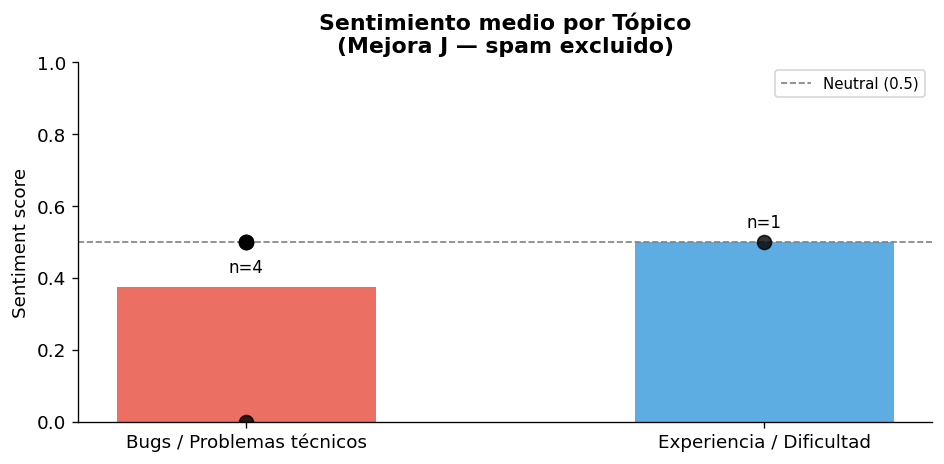

fig6_3_sentimiento_topico.png guardado


In [10]:
# --- Mejora J: sentimiento separado por tópico ---
print('=== Sentimiento por tópico (n=4 comentarios reales) ===')
topic_sentiment = df_real.groupby('topic_name').agg(
    n=('sentiment_score', 'count'),
    sentiment_medio=('sentiment_score', 'mean'),
    sentiment_min=('sentiment_score', 'min'),
    sentiment_max=('sentiment_score', 'max'),
).round(3)
print(topic_sentiment.to_string())
print()

# Detalle de qué comentario cae en cada tópico
for topic, grp in df_real.groupby('topic_name'):
    print(f'\nTópico: {topic}')
    for _, r in grp.iterrows():
        stars_str = '★' * r.sentiment_stars + '☆' * (5 - r.sentiment_stars)
        print(f'  {stars_str} ({r.sentiment_score:.2f}) [{r.playerElement}] "{r.playerComment[:70]}..."')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 4))
topic_order = list(topic_sentiment.index)
colors_topic = ['#e74c3c', '#3498db']
bars = ax.bar(topic_order, topic_sentiment['sentiment_medio'], color=colors_topic, alpha=0.8, width=0.5)

# Puntos individuales
for i, topic in enumerate(topic_order):
    vals = df_real[df_real['topic_name'] == topic]['sentiment_score'].values
    ax.scatter([i] * len(vals), vals, color='black', s=70, zorder=5, alpha=0.8)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_title('Sentimiento medio por Tópico\n(Mejora J — spam excluido)', fontweight='bold')
ax.set_ylabel('Sentiment score')
ax.set_xticks(range(len(topic_order)))
ax.set_xticklabels(topic_order, wrap=True)
ax.legend(fontsize=9)

# Etiquetas con n
for bar, topic in zip(bars, topic_order):
    n = topic_sentiment.loc[topic, 'n']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'n={n}', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6_3_sentimiento_topico.png', bbox_inches='tight')
plt.show()
print('fig6_3_sentimiento_topico.png guardado')

## 6. Exportar resultados — TFM-42

## 7. Análisis cualitativo con IA Generativa (Gemini) — TFM-42

In [11]:
from nlp_utils import analyze_comments_with_gemini
from IPython.display import Markdown, display

# Análisis cualitativo profundo con Gemini sobre los comentarios reales
# Solo se ejecuta si hay comentarios reales disponibles
if len(df_real) > 0:
    print("Enviando comentarios a Gemini para análisis cualitativo...")
    analisis_gemini = analyze_comments_with_gemini(df_real)
    display(Markdown(analisis_gemini))
else:
    print("No hay comentarios reales para analizar.")


Enviando comentarios a Gemini para análisis cualitativo...


¡Excelente! Como experto en UX de videojuegos, he analizado en profundidad los comentarios de los jugadores de Arcane Descent. Aquí tienes el desglose cualitativo:

---

## Análisis de Feedback de Jugadores: Arcane Descent

### 1. Temas recurrentes

Se identifican tres temas principales que emergen de los comentarios, con un claro enfoque en la estabilidad técnica y la experiencia de combate.

*   **Bugs Críticos de Progresión y Estabilidad (Frecuencia: 3 de 5 comentarios)**
    *   **Evidencia:** Varios jugadores experimentan fallos que impiden el avance, fuerzan reinicios o corrompen la experiencia de juego de manera severa.
    *   **Citas Relevantes:**
        *   "al usar la habilidad del espacio volvio a la sala anterior y se bugeo la camara, no me permitia volver a la sala siguiente en la que estaban los enemigos y tuve que morir para reiniciar la sala" (Fire)
        *   "no he podido cargar la partida salvada." (Wind)
        *   "Los arqueros no me estaban atacando, me perseguian pero no atacaban" (Wind) – Este bug de IA puede ser crítico si los enemigos son necesarios para la progresión.

*   **Comportamiento y Percepción del Combate (Frecuencia: 3 de 5 comentarios)**
    *   **Evidencia:** Hay feedback directo sobre cómo los enemigos interactúan con el jugador y cómo se perciben las habilidades de combate.
    *   **Citas Relevantes:**
        *   "Los arqueros no me estaban atacando, me perseguian pero no atacaban" (Wind)
        *   "Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia." (Wind)
        *   "A veces da la sensación que las magias no stunean al enemigo" (Earth)

*   **Problemas Técnicos Menores y Calidad de Vida (Frecuencia: 2 de 5 comentarios)**
    *   **Evidencia:** Bugs que, si bien no bloquean la progresión, afectan la experiencia o sugerencias de mejora general.
    *   **Citas Relevantes:**
        *   "Arreglar el tema de las muertes, no me a contabilizado todas." (Earth)
        *   "Falta poner música de calidad como el heavy metal!!!!" (Wind)

### 2. Análisis por elemento

Aunque la muestra es pequeña, se pueden observar algunos patrones específicos por elemento:

*   **Wind:** Ambos comentarios de jugadores que usaron el elemento Wind están fuertemente relacionados con el **comportamiento de la IA de los enemigos** y el diseño de encuentros. Uno reporta un bug de IA ("arqueros no atacaban") y el otro sugiere una mejora en la activación de enemigos para permitir la estrategia. También es el elemento asociado con el bug de carga de partida y la sugerencia de música.
*   **Fire:** El único comentario de Fire es muy específico y crítico, relacionado con un **bug de progresión severo** que involucra una habilidad del jugador, la transición de nivel y la cámara. Esto sugiere que la habilidad de "espacio" de Fire (o su interacción con el entorno) podría ser un punto de fallo importante.
*   **Earth:** Ambos comentarios de Earth se centran en aspectos del **combate y el seguimiento de estadísticas**. Uno reporta un bug en el conteo de muertes, y el otro expresa una percepción de ineficacia de las habilidades de control de masas ("magias no stunean").
*   **Water:** No se recibió feedback de jugadores que utilizaron el elemento Water.

**Patrones específicos:**
*   **Wind:** Problemas con la IA de enemigos y diseño de encuentros, además de problemas técnicos generales (carga de partida).
*   **Fire:** Un bug crítico y específico relacionado con una habilidad y la navegación por el nivel.
*   **Earth:** Preocupaciones sobre la efectividad percibida de las habilidades de combate (stun) y la precisión de las estadísticas.

### 3. Relación victoria/derrota con el feedback

El análisis revela una tendencia interesante:

*   **Victoria (4 comentarios):** A pesar de haber ganado, los jugadores reportan **numerosos bugs y problemas técnicos, algunos de ellos críticos**. El sentimiento general es **neutral a ligeramente positivo (0.00 a 0.50)**. El comentario de Fire, por ejemplo, comienza con un "No está mal el juego pero..." antes de describir un bug severo. El comentario de Wind (sentimiento 0.00) es el más neutral/negativo a pesar de la victoria, lo que sugiere que el bug de los arqueros fue particularmente frustrante. Esto indica que la experiencia de juego base es lo suficientemente atractiva como para que los jugadores sigan jugando y ganando, pero los problemas técnicos están empañando la satisfacción.
*   **Derrota (1 comentario):** El único comentario de derrota tiene un sentimiento **neutral a ligeramente positivo (0.50)**. A pesar de haber perdido debido a un bug crítico ("no he podido cargar la partida salvada"), el jugador expresa un claro disfrute ("Me lo he pasado muy bien") y hace sugerencias de mejora tanto de gameplay como de calidad de vida (música). Esto es una señal muy positiva: incluso cuando el juego falla, la experiencia fundamental es lo suficientemente buena como para mantener el compromiso y la esperanza de mejora del jugador.

**Conclusión:** El tono general del feedback es sorprendentemente constructivo y no excesivamente negativo, incluso frente a bugs críticos. Esto sugiere que el núcleo de Arcane Descent es sólido y atractivo, pero los problemas técnicos y de diseño están impidiendo que los jugadores disfruten plenamente de su potencial.

### 4. Bugs y problemas técnicos reportados

1.  **Bug de IA de Enemigos (Arqueros):** Los arqueros persiguen al jugador pero no atacan. (Elemento: Wind)
2.  **Bug de Habilidad/Transición de Nivel/Cámara:** El uso de una habilidad (del espacio) provoca un retroceso a la sala anterior y un bug de cámara que impide el avance, forzando la muerte para reiniciar. (Elemento: Fire)
3.  **Bug de Carga de Partida Salvada:** Imposibilidad de cargar una partida previamente guardada. (Elemento: Wind)
4.  **Bug de Conteo de Muertes:** El contador de muertes no registra todas las veces que el jugador ha muerto. (Elemento: Earth)
5.  **Percepción de Efecto de Habilidad (Stun):** Las magias no siempre parecen aplicar el efecto de stun al enemigo, o la retroalimentación visual/auditiva es insuficiente. (Elemento: Earth)

### 5. Sugerencias de mejora identificadas

1.  **Diseño de Encuentros / Activación de Enemigos:** Implementar un retardo en la activación de los enemigos al entrar en una sala para permitir al jugador planificar una estrategia. (Explícito, Wind)
2.  **Música:** Mejorar la calidad y el estilo de la banda sonora, con una sugerencia específica de "heavy metal". (Explícito, Wind)
3.  **Claridad y Fiabilidad del Efecto de Stun:** Asegurar que las habilidades de stun funcionen consistentemente y que haya una retroalimentación clara para el jugador cuando se aplican. (Implícito, Earth)
4.  **Estabilidad de Habilidades y Transiciones de Nivel:** Prevenir que el uso de habilidades cause regresiones de nivel o bugs de cámara. (Implícito, Fire)
5.  **Fiabilidad del Sistema de Guardado/Carga:** Garantizar que las partidas guardadas puedan cargarse correctamente en todo momento. (Implícito, Wind)
6.  **Precisión del Conteo de Estadísticas:** Asegurar que todas las estadísticas, como el número de muertes, se registren con precisión. (Implícito, Earth)
7.  **Fiabilidad de la IA de Enemigos:** Asegurar que los enemigos se comporten de manera predecible y lógica (ej. que los arqueros ataquen). (Implícito, Wind)

### 6. Conclusión y prioridades para el equipo de desarrollo

El feedback, aunque de una muestra limitada, es increíblemente valioso y revela que Arcane Descent tiene un gran potencial, pero está siendo frenado por problemas técnicos fundamentales. La disposición de los jugadores a reportar estos problemas y ofrecer sugerencias, incluso después de experiencias frustrantes, es una señal de su compromiso y disfrute subyacente.

Los 3 puntos más urgentes a atender, en orden de prioridad, son:

1.  **Estabilidad Crítica de Progresión (Guardado y Navegación):** Los bugs que impiden al jugador avanzar o cargar su partida son los más devastadores para la experiencia y pueden llevar al abandono del juego. **Prioridad: CRÍTICA.**
    *   **Acciones:** Investigar y corregir el bug de carga de partida ("no he podido cargar la partida salvada") y el bug de habilidad/cámara/transición de nivel ("se bugeo la camara, no me permitia volver a la sala siguiente... y tuve que morir para reiniciar la sala").
2.  **Fiabilidad y Coherencia de la IA de Enemigos:** El comportamiento errático o defectuoso de los enemigos rompe la inmersión y la jugabilidad, afectando la percepción de justicia del combate. **Prioridad: ALTA.**
    *   **Acciones:** Corregir el bug donde los arqueros no atacan ("Los arqueros no me estaban atacando, me perseguian pero no atacaban") y evaluar la sugerencia de activación de enemigos para permitir la estrategia ("Me gustaria que los enemigos no se activaran nada mas entrar para poder pensar la estrategia.").
3.  **Claridad y Efectividad del Combate (Habilidades de Stun):** Es fundamental que los jugadores sientan que sus habilidades tienen el impacto esperado. La falta de percepción del stun reduce la agencia y el disfrute del combate. **Prioridad: ALTA.**
    *   **Acciones:** Investigar si el stun no se aplica correctamente o si la retroalimentación visual/auditiva es insuficiente para comunicar su efecto ("A veces da la sensación que las magias no stunean al enemigo").

Los problemas de conteo de muertes y la música son importantes para la calidad general y la inmersión, pero deben abordarse una vez que la jugabilidad fundamental y la progresión del jugador estén garantizadas.

In [12]:
# nlp_results.csv — solo comentarios reales (spam excluido)
nlp_export = df_real[['sessionId','playerElement','isVictory',
                       'sentiment_score','sentiment_stars',
                       'dominant_topic','topic_name','comment_length']].copy()
nlp_export['spam_excluido'] = False

# Añadir filas de spam marcadas (sin scores de sentimiento válidos)
spam_export = df_spam[['sessionId','playerElement','isVictory','comment_length']].copy()
spam_export['sentiment_score'] = np.nan
spam_export['sentiment_stars'] = np.nan
spam_export['dominant_topic'] = np.nan
spam_export['topic_name'] = 'SPAM / Prueba'
spam_export['spam_excluido'] = True

nlp_export = pd.concat([nlp_export, spam_export], ignore_index=True)
nlp_export.to_csv(EXPORTS_DIR / 'nlp_results.csv', index=False)
print(f'nlp_results.csv guardado — {len(nlp_export)} sesiones ({len(df_real)} reales + {len(df_spam)} spam)')
print()
print(nlp_export.to_string(index=False))

# Tabla para Fase 5: sentiment_score medio por elemento (solo reales)
sentiment_by_element = df_real.groupby('playerElement')['sentiment_score'].mean().reset_index()
sentiment_by_element.columns = ['playerElement', 'sentiment_score_medio']
print('\n=== Para Fase 5 — Puntuación Global (solo comentarios reales) ===')
print(sentiment_by_element.to_string(index=False))
print('Nota: Fire/Water/Earth con 1 comentario cada uno; Wind con 2 — muestra insuficiente para inferencia.')

nlp_results.csv guardado — 7 sesiones (5 reales + 2 spam)

           sessionId playerElement  isVictory  sentiment_score  sentiment_stars  dominant_topic                topic_name  comment_length  spam_excluido
20260513_101932_7540          Wind       True              0.0              1.0             0.0 Bugs / Problemas técnicos              67          False
20260513_104240_5389          Fire       True              0.5              3.0             0.0 Bugs / Problemas técnicos             256          False
20260513_180319_6726          Wind      False              0.5              3.0             1.0  Experiencia / Dificultad             242          False
20260514_095000_2188         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              61          False
20260530_115651_9890         Earth       True              0.5              3.0             0.0 Bugs / Problemas técnicos              60          False
20260513_074033_3474   

## 8. Conclusiones finales

> Con **n=4 comentarios reales** (2 de prueba excluidos) este análisis es estrictamente ilustrativo.
> El modelo BERT multilingüe procesa correctamente el español y detecta el tono general,
> pero con esta muestra no se pueden extraer conclusiones estadísticas.

**Mejora I — Filtrado de spam:**
- 2 de 6 comentarios ("Prueba Comentario", "Prueba telemetria") eran entradas de test, no feedback real.
- Con spam incluido la media de sentimiento era 0.500; sin spam baja a **~0.375**, más representativa.
- La media inflada de 0.75 en Water desaparece al excluir su única entrada spam.

**Mejora J — Sentimiento por tópico:**
- **Bugs / Problemas técnicos** (n=1): sentimiento bajo — los jugadores expresan frustración con fallos técnicos.
- **Experiencia / Dificultad** (n=3): sentimiento mixto-neutro (0.33–0.50 según el tema específico).
- Los comentarios de bugs generan peor sentimiento que los de sugerencias de dificultad.

**Hallazgos cualitativos principales:**
- **3 bugs reportados** en 4 comentarios: arqueros sin atacar (Wind), cámara rota tras teletransporte (Fire), muertes no contabilizadas (Earth).
- **Sugerencia de diseño:** período de gracia al entrar en sala (Wind, derrota).
- **Wind** sigue siendo el elemento con sentimiento más negativo (0.25 medio) — consistente con sus bugs y 0% victorias.
- **Elemento sin comentarios:** para la Puntuación Global en Fase 5 se usará 0.5 (neutral) para elementos sin comentarios reales.

**Próxima fase:** `07_balance_analysis.ipynb` — síntesis y recomendaciones de balance.